
# Regression Model: Predicting Final Student Grade
## Linear Regression Analysis

This notebook implements a **Linear Regression model** to predict students’ final grades.


### Target Variable Explanation

In this dataset:
- **G1** represents the first period grade
- **G2** represents the second period grade
- **G3** represents the **final grade**

The objective of this regression model is to predict **G3**, as it reflects
the student’s final academic performance and is the most meaningful outcome variable.


In [9]:

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [10]:

# Load cleaned dataset (robust path handling)
candidate_paths = [
    "../data/processed/student_cleaned.csv",
    "./data/processed/student_cleaned.csv",
    "student_cleaned.csv"
]

df = None
for p in candidate_paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f"Loaded dataset from: {p}")
        break

if df is None:
    raise FileNotFoundError("student_cleaned.csv not found")
    
df.head()


Loaded dataset from: ../data/processed/student_cleaned.csv


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,G3
0,1.023046,1.143856,1.360371,0.792251,-0.042286,-0.449944,0.062194,-0.236010,0.801479,-0.540699,...,False,True,False,False,False,True,True,False,False,6
1,0.238380,-1.600009,-1.399970,-0.643249,-0.042286,-0.449944,1.178860,-0.236010,-0.097908,-0.540699,...,False,False,True,False,False,False,True,True,False,6
2,-1.330954,-1.600009,-1.399970,-0.643249,-0.042286,3.589323,0.062194,-0.236010,-0.997295,0.583385,...,False,True,False,True,False,True,True,True,False,10
3,-1.330954,1.143856,-0.479857,-0.643249,1.150779,-0.449944,-1.054472,-1.238419,-0.997295,-0.540699,...,False,False,True,True,True,True,True,True,True,15
4,-0.546287,0.229234,0.440257,-0.643249,-0.042286,-0.449944,0.062194,-0.236010,-0.997295,-0.540699,...,False,False,True,True,False,True,True,False,False,10



## 1) Problem Definition & Target Variable

**Objective:**  
Predict the **final student grade (G3)** using academic and demographic features.

This is a **regression problem** because the target variable is numeric and continuous.


In [11]:

X = df.drop(columns=["G3"])
y = df["G3"]

X.shape, y.shape


((395, 41), (395,))


## 2) Train-Test Split

The dataset is split into:
- **80% training data**
- **20% testing data**

This allows us to evaluate the model on unseen observations.


In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



## 3) Linear Regression Model Training

We train a **Multiple Linear Regression** model using scikit-learn.


In [13]:

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False



## 4) Model Evaluation (Required Metrics)

We evaluate the regression model using:
- **R² Score** (variance explained)
- **Mean Squared Error (MSE)**
- **Root Mean Squared Error (RMSE)**


In [14]:

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")


R² Score: 0.724
MSE: 5.657
RMSE: 2.378



### Evaluation Insights
- A higher R² value indicates better explanatory power.
- RMSE represents the average prediction error in grade points.



## 5) Actual vs Predicted Grades

This scatter plot compares true final grades with model predictions.
The red dashed line represents perfect prediction.


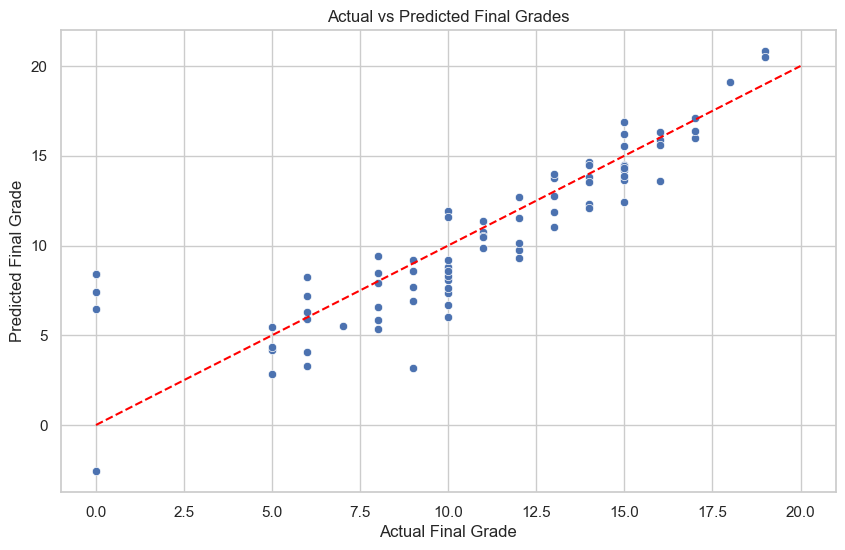

In [15]:

ax = sns.scatterplot(x=y_test, y=y_pred)
ax.set_xlabel("Actual Final Grade")
ax.set_ylabel("Predicted Final Grade")
ax.set_title("Actual vs Predicted Final Grades")
plt.plot([0, 20], [0, 20], color="red", linestyle="--")
plt.show()



## 6) Feature Importance (Regression Coefficients)

Linear Regression coefficients indicate how much each feature
affects the final grade while holding others constant.


In [16]:

coefficients = (
    pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": model.coef_
    })
    .sort_values(by="Coefficient", ascending=False)
)

coefficients.head(10)


,Feature,Coefficient
14,G2,3.598101
33,schoolsup_yes,0.785652
13,G1,0.701779
24,Fjob_health,0.481242
12,absences,0.444350
38,higher_yes,0.375377
16,sex_M,0.374410
29,reason_other,0.304973
6,famrel,0.282056
8,goout,0.211099



### Feature Importance Insights
- **Previous grades (G1, G2)** are the strongest predictors of final performance.
- **Study time** positively affects grades.
- **Failures** have a strong negative impact.
- Socio-demographic features contribute less compared to academic history.



## 7) Conclusion

- The Linear Regression model successfully predicts student final grades.
- Academic-related variables dominate prediction power.
- The model meets the regression requirements of the project and complements
  the classification model used elsewhere in the analysis.
